# Proyecto de árbol de decisión

En este notebook voy a hacer el proyecto paso a paso.  
La idea es revisar un poco los datos, limpiarlos, seleccionar algunas variables y después entrenar un árbol de decisión para predecir si una persona tiene diabetes o no.

## 1. Importar librerías

Primero importo las librerías que voy a usar.  
Las dejo todas juntas al principio para tener el notebook más ordenado.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from pickle import dump

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

## 2. Cargar los datos

Aquí cargo el dataset desde la URL del ejercicio para trabajar directamente con él.

In [2]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"
total_data = pd.read_csv(url)
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Revisión rápida

Antes de entrenar el modelo, miro el tamaño del dataset, los duplicados y los nulos para ver si hay algo que limpiar.

In [3]:
total_data.shape

(768, 9)

In [4]:
total_data.duplicated().sum()

np.int64(0)

In [5]:
total_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 4. Limpieza

En este caso elimino duplicados para quedarme con el dataset limpio antes de seguir.

In [6]:
total_data = total_data.drop_duplicates().reset_index(drop=True)
total_data.shape

(768, 9)

## 5. EDA sencillo

Aquí hago una revisión visual básica.  
Primero miro cómo está repartida la variable objetivo y luego reviso un poco las variables numéricas.

In [7]:
total_data["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

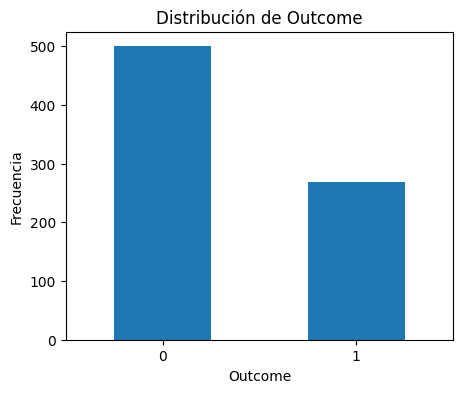

In [8]:
plt.figure(figsize=(5,4))
total_data["Outcome"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de Outcome")
plt.xlabel("Outcome")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

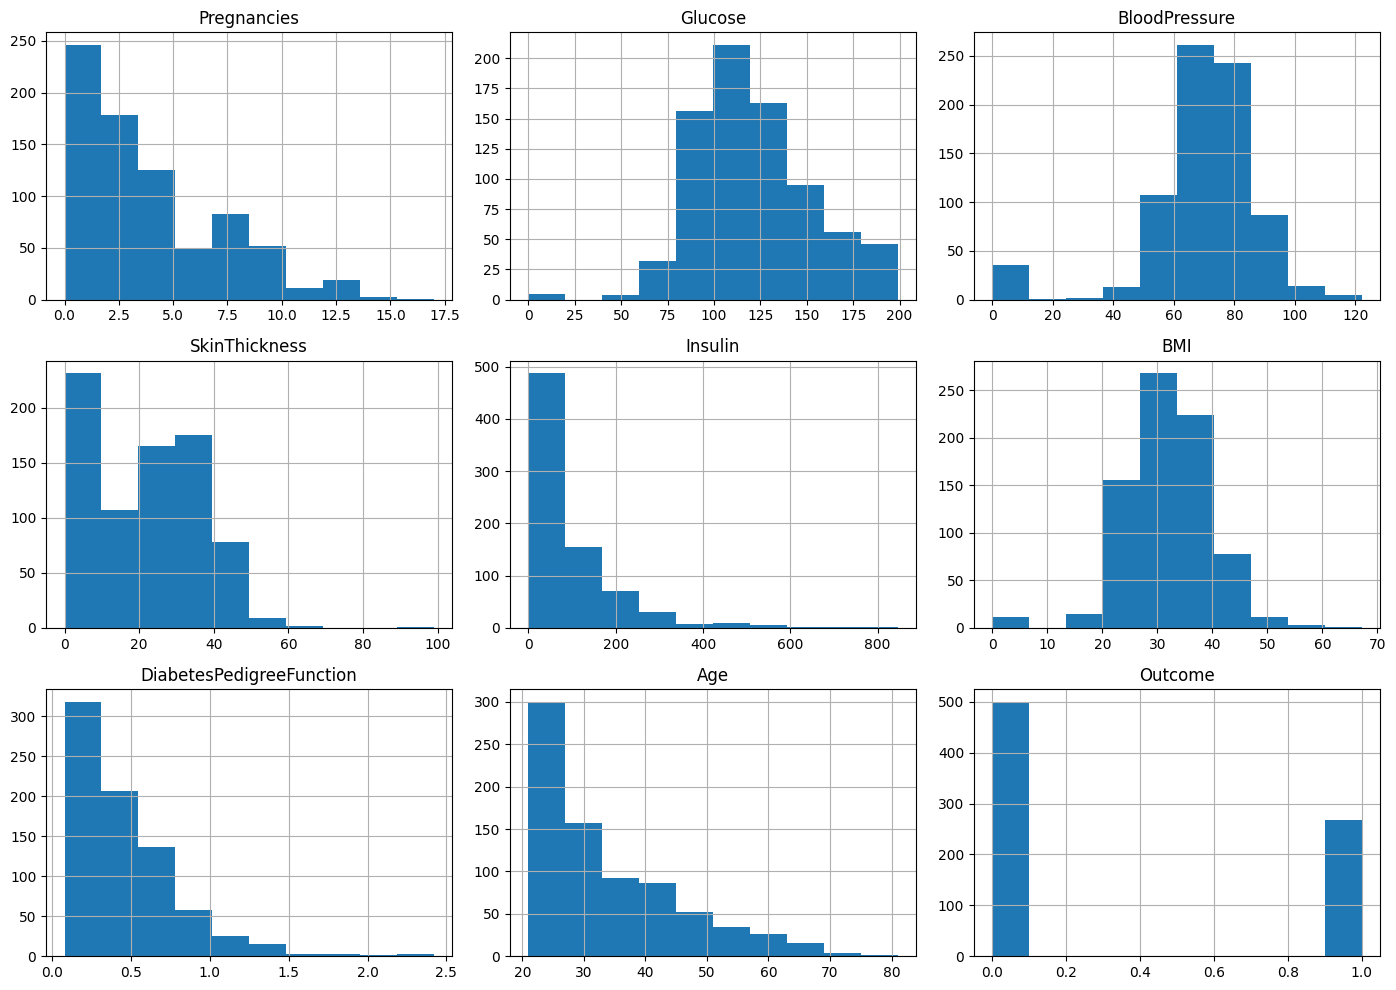

In [9]:
total_data.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

También hago una matriz de correlación para ver un poco qué variables parecen tener más relación entre sí y con la variable objetivo.

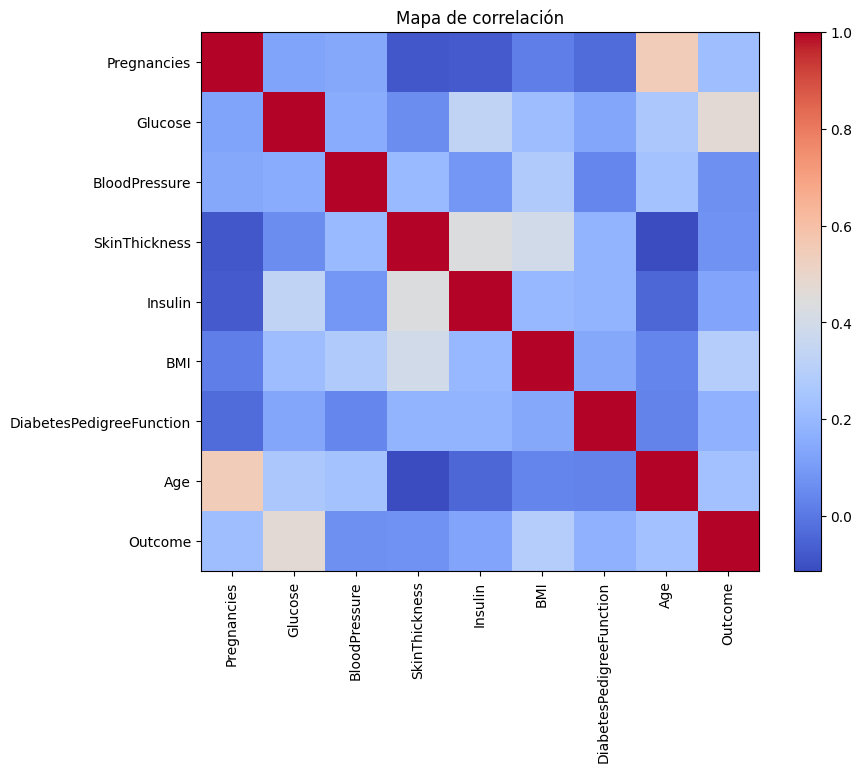

In [10]:
corr = total_data.corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Mapa de correlación")
plt.show()

## 6. Selección de variables

Aquí separo X e y, hago train y test, y luego me quedo con 7 variables usando `SelectKBest`.  
No es la única forma de hacerlo, pero para este ejercicio me sirve bastante bien.

In [11]:
X = total_data.drop("Outcome", axis=1)
y = total_data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

selection_model = SelectKBest(k=7)
selection_model.fit(X_train, y_train)

selected_columns = X_train.columns[selection_model.get_support()]
selected_columns

Index(['Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age'],
      dtype='str')

In [12]:
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns=selected_columns)
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns=selected_columns)

X_train_sel.head()

,Pregnancies,Glucose,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1.0,90.0,12.0,43.0,27.2,0.580,24.0
1,5.0,126.0,27.0,22.0,29.6,0.439,40.0
2,2.0,105.0,40.0,94.0,34.9,0.225,25.0
3,1.0,146.0,0.0,0.0,29.7,0.564,29.0
4,0.0,95.0,39.0,105.0,44.6,0.366,22.0


## 7. Guardar datos procesados

Guardo una copia del train y del test por si quiero reutilizarlos más tarde.

In [13]:
X_train_sel["Outcome"] = y_train.values
X_test_sel["Outcome"] = y_test.values

os.makedirs("data/processed", exist_ok=True)

X_train_sel.to_csv("data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("data/processed/clean_test.csv", index=False)

In [14]:
train_data = pd.read_csv("data/processed/clean_train.csv")
test_data = pd.read_csv("data/processed/clean_test.csv")

train_data.head()

,Pregnancies,Glucose,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.0,90.0,12.0,43.0,27.2,0.580,24.0,0
1,5.0,126.0,27.0,22.0,29.6,0.439,40.0,0
2,2.0,105.0,40.0,94.0,34.9,0.225,25.0,0
3,1.0,146.0,0.0,0.0,29.7,0.564,29.0,0
4,0.0,95.0,39.0,105.0,44.6,0.366,22.0,0


## 8. Modelo de árbol de decisión

Ahora entreno un árbol de decisión básico con las variables seleccionadas.

In [15]:
X_train = train_data.drop("Outcome", axis=1)
y_train = train_data["Outcome"]

X_test = test_data.drop("Outcome", axis=1)
y_test = test_data["Outcome"]

In [16]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

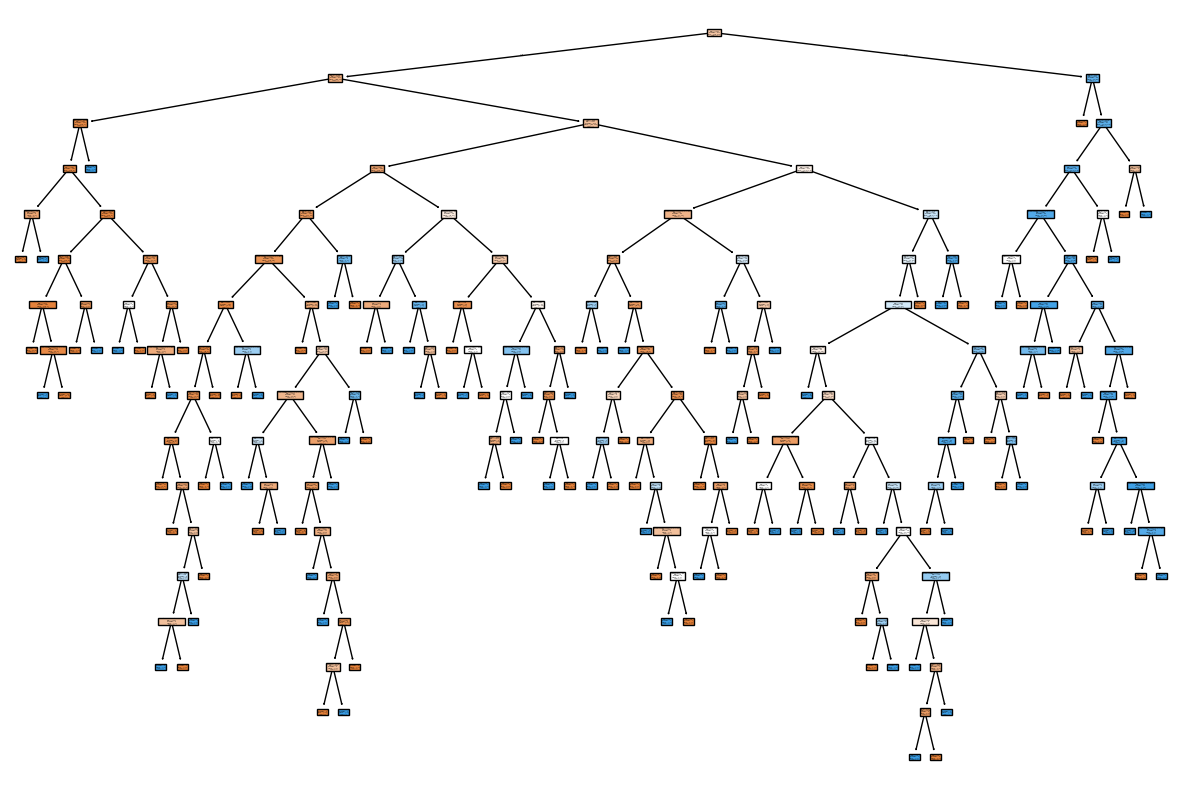

In [17]:
plt.figure(figsize=(15, 10))
plot_tree(model, feature_names=list(X_train.columns), class_names=["0", "1"], filled=True)
plt.show()

In [18]:
y_pred = model.predict(X_test)
y_pred[:10]

array([1, 0, 0, 1, 0, 0, 0, 1, 0, 1])

In [19]:
accuracy_score(y_test, y_pred)

0.6883116883116883

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.81      0.77       100
           1       0.57      0.46      0.51        54

    accuracy                           0.69       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.68      0.69      0.68       154



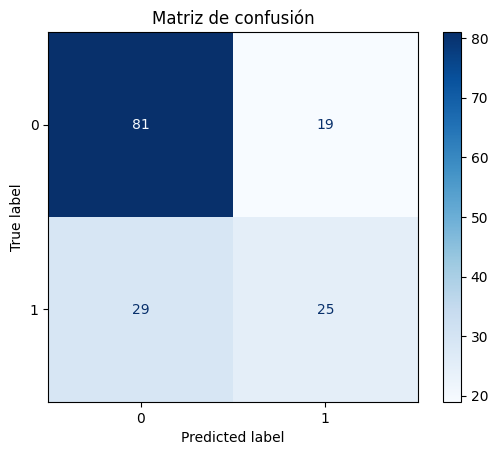

In [21]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

## 9. Pequeña optimización

Pruebo algunos hiperparámetros para ver si consigo mejorar un poco el resultado del árbol.

In [22]:
hyperparams = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    hyperparams,
    scoring="accuracy",
    cv=5
)

grid.fit(X_train, y_train)

grid.best_params_

{'criterion': 'entropy',
 'max_depth': 3,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [23]:
grid.best_score_

np.float64(0.7492869518859122)

In [24]:
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

y_pred_opt = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))
print("Accuracy:", accuracy_score(y_test, y_pred_opt))

[[92  8]
 [39 15]]
              precision    recall  f1-score   support

           0       0.70      0.92      0.80       100
           1       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154

Accuracy: 0.6948051948051948


## 10. Guardar el modelo

Por último guardo el modelo final para poder reutilizarlo después sin tener que volver a entrenarlo.

In [25]:
os.makedirs("models", exist_ok=True)
dump(best_model, open("models/decision_tree_diabetes.sav", "wb"))

## Conclusión

En este proyecto he cargado el dataset, he hecho una revisión rápida, he eliminado duplicados, he seleccionado algunas variables y he entrenado un árbol de decisión.

Después he probado una pequeña optimización con `GridSearchCV` para ver si podía mejorar el resultado inicial.  
No es un análisis súper avanzado, pero me sirve para entender mejor cómo montar un modelo de clasificación con árboles de decisión paso a paso.